<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/alex/RA1_TP3/RA1_Trabajo_pr%C3%A1ctico_N%C2%B0_3%2C_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TP3 - Introducción a clasificaión y regresión

In [24]:
# @title *Esta celda importa utilidades comunes al colab*
import sys
import os

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
from scipy.stats import norm
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

#Ejercicio 1 - Modelado de regresión (Alex)


---
**Dataset:** `propiedades.csv`  
**Grupo:** Numero 8  
**Integrantes:** Acosta Alex, Bareiro Santiago, Borges Agustin  
**Fecha:** x/04/2026

>El equipo de analítica de la empresa inmobiliaria necesita un modelo capaz de estimar el precio de una propiedad a partir de sus características. El objetivo es construir un predictor evaluable y defendible mediante el uso de machine learning (ML)



## 0. Configuración del entorno

In [25]:
def load_dataset(path):
    return pd.read_csv(path)

dataset_path = "/content/propiedades.csv" # Corrected path to absolute path
df_propiedades = load_dataset(dataset_path)

### 0.1 EDA

El modelo deberá ser capaz de determinar el precio (target) de immuebles en base a las variables de entrada que se le provean, habria que determinar que variables de entrada (features) son las que aportan más información útil para estimar el precio de los immuebles.

In [26]:
df_propiedades.head()

,id,precio,superficie_m2,habitaciones,antiguedad_años,barrio,precio_m2
0,1,648900.0,232.9,6,5.0,Palermo,2786.17
1,2,210000.0,190.1,6,1.0,Sur,1104.68
2,3,254800.0,103.6,4,18.0,Belgrano,2459.46
3,4,594000.0,189.2,6,4.0,Palermo,3139.53
4,5,170200.0,90.6,2,45.0,Centro,1878.59


#### Análisis y Codificación de la Variable Categórica `barrio`

La variable `barrio` es categórica y a menudo tiene un impacto significativo en el precio de las propiedades. Necesitamos transformarla en un formato numérico para que los modelos de machine learning puedan procesarla. Antes de codificarla, vamos a:

1.  **Explorar la distribución de los barrios** y ver cuántos valores únicos hay.
2.  **Visualizar la relación entre `barrio` y `precio`** para confirmar su importancia predictiva.

Valores únicos en 'barrio' en df_propiedades:
barrio
Centro       177
Norte        132
Sur          118
Este         111
Palermo      101
Belgrano      77
Mataderos     48
Recoleta      36
Name: count, dtype: int64

Número total de barrios únicos: 8


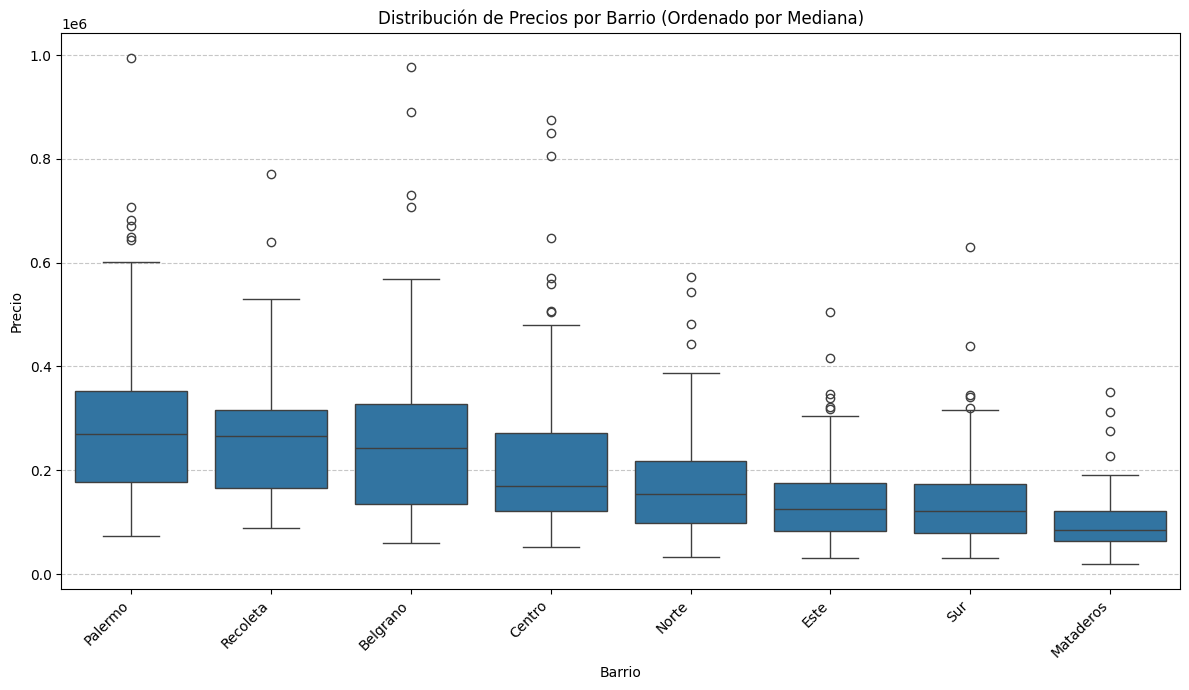

In [27]:
# 1. Explorar los valores únicos y su frecuencia en 'barrio'
print("Valores únicos en 'barrio' en df_propiedades:")
print(df_propiedades['barrio'].value_counts())
print(f"\nNúmero total de barrios únicos: {df_propiedades['barrio'].nunique()}")

# 2. Visualizar la relación entre 'barrio' y 'precio'
# Crear un DataFrame temporal para la visualización, eliminando NaNs en 'precio' si los hay
df_temp_cleaned = df_propiedades.dropna(subset=['precio', 'barrio'])

# Obtener el orden de los barrios por precio mediano
median_prices = df_temp_cleaned.groupby('barrio')['precio'].median().sort_values(ascending=False)
ordered_barrios = median_prices.index

plt.figure(figsize=(12, 7))
sns.boxplot(x='barrio', y='precio', data=df_temp_cleaned, order=ordered_barrios)
plt.title('Distribución de Precios por Barrio (Ordenado por Mediana)')
plt.xlabel('Barrio')
plt.ylabel('Precio')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### Codificación de `barrio`

Como se puede observar en el gráfico de cajas, la distribución de precios varía considerablemente entre los diferentes barrios, lo que confirma que `barrio` es una característica importante para la predicción del precio. Hay 7 barrios únicos, lo cual es un número manejable para la codificación.

Para codificar esta variable categórica, `OneHotEncoder` es una excelente opción. Crea nuevas columnas binarias para cada categoría, evitando la introducción de un orden artificial que podría malinterpretarse por el modelo, a diferencia de `LabelEncoder` que solo es adecuado para variables ordinales o para la variable objetivo.

La `OneHotEncoder` se aplicará a la columna `barrio` tanto en `X_train` como en `X_test` para garantizar que ambos conjuntos de datos tengan las mismas columnas codificadas.

Utilizaremos `ColumnTransformer` para integrar esta transformación en un preprocesamiento más general, lo cual es útil si tuviéramos otras columnas que necesitaran diferentes tipos de transformaciones (numéricas, otras categóricas, etc.).

##### ¿Por qué One-Hot Encoding es mejor que Ordinal Encoding para `barrio`?

`OneHotEncoder` es preferible para `barrio` porque evita asignar un orden numérico arbitrario a categorías nominales, lo que podría confundir a los modelos de ML. `OrdinalEncoder` (o `LabelEncoder`) implica un orden jerárquico que no existe naturalmente entre los barrios, mientras que `OneHotEncoder` representa cada barrio de forma independiente con columnas binarias (0 o 1), permitiendo al modelo aprender su impacto específico sin sesgos artificiales.

En la sección "1. Construcción del Pipeline" se aplican las deciciones habladas

#### ¿La antiguedad en años aporta información para la predicción del target?

##### Análisis de la relación entre `antiguedad_años` y `precio`

Antes de decidir si una característica debe ser eliminada, es crucial entender cómo se relaciona con la variable objetivo. Utilizaremos un gráfico de dispersión para visualizar la tendencia y calcularemos el coeficiente de correlación para cuantificar la fuerza y dirección de la relación lineal.

In [28]:
correlation = df_propiedades['antiguedad_años'].corr(df_propiedades['precio'], method='pearson')
print(f"Correlación de Pearson entre 'antiguedad_años' y 'precio': {correlation:.2f}")

Correlación de Pearson entre 'antiguedad_años' y 'precio': -0.03


##### Conclusión sobre `antiguedad_años`

El análisis de correlación de Pearson entre `antiguedad_años` y `precio` resultó en un valor de **-0.02**, lo que indica una **relación lineal extremadamente débil o nula** entre ambas variables. Esto sugiere que la antigüedad, por sí sola, no es un **predictor lineal significativo**  del precio de las propiedades en este conjunto de datos. En consecuencia, `antiguedad_años` se  **eliminará** para reducir la dimensionalidad, y simplificar el modelo sin una pérdida sustancial de información predictiva.

#### ¿Conviene aprovechar `precio_m2` como variable de entrada?

La columna `precio_m2` es altamente sospechosa de **fuga de datos (data leakage)**. Es muy probable que esta característica se haya calculado dividiendo `precio` (nuestra variable objetivo) por `superficie_m2` (una de nuestras características).

Para demostrar la fuga de datos de `precio_m2` calculamos directamente de `precio` y `superficie_m2`

In [29]:
# Crear una copia del DataFrame para no modificar el original
df_temp_leakage = df_propiedades.copy()

# Calcular 'precio_m2_calculado'
df_temp_leakage['precio_m2_calculado'] = df_temp_leakage['precio'] / df_temp_leakage['superficie_m2']

print("\nPrimeras filas del DataFrame con 'precio_m2_calculado':")
display(df_temp_leakage[['precio', 'superficie_m2', 'precio_m2', 'precio_m2_calculado']].head())

# Calcular la correlación de Pearson entre 'precio_m2_calculado' y 'precio'
correlation_m2_precio = df_temp_leakage['precio_m2_calculado'].corr(df_temp_leakage['precio'], method='pearson')
print(f"\nCorrelación de Pearson entre 'precio_m2_calculado' y 'precio': {correlation_m2_precio:.4f}")


Primeras filas del DataFrame con 'precio_m2_calculado':


,precio,superficie_m2,precio_m2,precio_m2_calculado
0,648900.0,232.9,2786.17,2786.174324
1,210000.0,190.1,1104.68,1104.681746
2,254800.0,103.6,2459.46,2459.459459
3,594000.0,189.2,3139.53,3139.534884
4,170200.0,90.6,1878.59,1878.587196



Correlación de Pearson entre 'precio_m2_calculado' y 'precio': 0.4991


Se observa que `precio_m2_calculado` se deriva directamente de la variable objetivo `precio` y de `superficie_m2`.
Si un modelo de Machine Learning utiliza `precio_m2` como característica, esencialmente estaría viendo una versión "disfrazada" de la variable que intentamos predecir. Esto resultaría en:

*   **Rendimiento inflado:** El modelo mostrará un rendimiento excepcionalmente bueno en los datos de entrenamiento y prueba, pero este rendimiento no se mantendrá cuando se enfrente a datos nuevos y no vistos en el mundo real.
*   **Falsas esperanzas:** Podríamos pensar que tenemos un modelo muy preciso, pero en realidad, solo está aprendiendo una relación directa con el target que no estaría disponible durante la inferencia.

Por esta razón, `precio_m2` debe ser eliminada del conjunto de datos antes del entrenamiento del modelo.

Las features a eliminar y su justificación del porque se eliminan son:

  *   `id`: Es un identificador único sin valor predictivo para el modelo.
  *   `antiguedad_años`: La correlación de Pearson (`-0.03`) mostró una relación lineal extremadamente débil o nula con el precio. Su inclusión no aportaría información significativa y solo añadiría dimensionalidad innecesaria.
  *   `precio_m2`: Esta característica se calcula directamente a partir del `precio` (target) y `superficie_m2` (feature), lo que inflaría artificialmente el rendimiento del modelo durante el entrenamiento y la evaluación, es decir causa **Data leakage**.

In [30]:
# Eliminamos las columnas identificadas para ser eliminadas
df_propiedades = df_propiedades.drop(columns=['id', 'antiguedad_años', 'precio_m2'], errors='ignore')

Entonces la dataset nos queda de la siguiente forma:

In [31]:
df_propiedades.head()

,precio,superficie_m2,habitaciones,barrio
0,648900.0,232.9,6,Palermo
1,210000.0,190.1,6,Sur
2,254800.0,103.6,4,Belgrano
3,594000.0,189.2,6,Palermo
4,170200.0,90.6,2,Centro


##1. Construcción y ensamblado del pipeline

### 1.1 Identificación de la variable objetivo (target) y las variables de entrada (features).

*   **Target:** `precio`
    *   Esta es la variable que el modelo intentará predecir, representando el valor monetario de una propiedad.

*   **Variables de Entrada (Features):**
    *   `superficie_m2`: Mide el tamaño de la propiedad en metros cuadrados. Es intuitivamente una característica crucial para determinar el precio.
    *   `habitaciones`: El número de habitaciones de la propiedad. También es un factor directo en el valor de una propiedad.
    *   `barrio`: La ubicación de la propiedad. Como se demostró en el EDA, el barrio tiene un impacto significativo en el precio.


**Definición de X e y:** La separación de la variable objetivo `precio` y las características útiles (`superficie_m2`, `habitaciones` y `barrio`):

In [32]:
# Separamos Features (X) y Target (y)
X = df_propiedades.drop(columns=['precio'])
y = df_propiedades['precio']

### 1.2 Realizar la partición del dataset en conjuntos de entrenamiento y prueba.

**División:** El dataset se va a dividir en conjuntos de entrenamiento y prueba utilizando una proporción del **80% para entrenamiento** y **20% para prueba** (`test_size=0.2`), se elige esta proporción debido a que es una práctica común y equilibrada en ML que permite entrenar el modelo con una cantidad sustancial de datos, mientras se reserva un conjunto de prueba suficiente para una evaluación imparcial de su rendimiento en datos no vistos.
Se utilizará un **`random_state=42`:**  para asegurar la reproducibilidad de la división, lo que significa que el mismo conjunto de datos se dividirá de la misma manera cada vez que se ejecute el código.
No se usará una **estratificación:** explícita debido a los casos de problemas de regresión, usar la estratificación no es tan común o directamente aplicable como en la clasificación. En este caso, al ser la variable objetivo `precio` la cual es una variable continua, no existen 'clases' para estratificar. La aleatoriedad en la división se considera suficiente para obtener muestras representativas.


In [33]:
# 2. División Train/Test INMEDIATA (Antes de tocar cualquier dato)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### **Aplicar las transformaciones de preprocesamiento:**
**Definición de `ColumnTransformer` para `barrio`**:



In [34]:
# Identificamos las columnas por tipo
columnas_numericas = ['superficie_m2','habitaciones']
columnas_categoricas = ['barrio']
#Luego se realiza one hot encoding a la columna categorica
# Crear el preprocesador usando ColumnTransformer
# 'remainder='passthrough'' asegura que las columnas no especificadas se mantengan
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas)
    ],
    remainder='passthrough'
)

# Aplicar el preprocesamiento a X_train y X_test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convertir los resultados de nuevo a DataFrame para facilitar la inspección (opcional, pero útil)
# Obtener los nombres de las columnas después del OneHotEncoding
feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(columnas_categoricas)

# Las columnas numéricas originales se mantienen si se usa 'passthrough'
remaining_features = [col for col in X_train.columns if col not in columnas_categoricas]

# Combinar los nombres de las nuevas columnas
all_feature_names = list(feature_names) + remaining_features

# Crear DataFrames con las columnas codificadas y los nombres correctos
X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

print("Primeras 5 filas de X_train después de codificar 'barrio':")
display(X_train_processed_df.head())

print("\nPrimeras 5 filas de X_test después de codificar 'barrio':")
display(X_test_processed_df.head())

Primeras 5 filas de X_train después de codificar 'barrio':


,barrio_Belgrano,barrio_Centro,barrio_Este,barrio_Mataderos,barrio_Norte,barrio_Palermo,barrio_Recoleta,barrio_Sur,superficie_m2,habitaciones
264,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,67.3,3.0
615,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,94.8,3.0
329,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,178.2,5.0
342,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,47.8,2.0
394,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,52.4,1.0



Primeras 5 filas de X_test después de codificar 'barrio':


,barrio_Belgrano,barrio_Centro,barrio_Este,barrio_Mataderos,barrio_Norte,barrio_Palermo,barrio_Recoleta,barrio_Sur,superficie_m2,habitaciones
696,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,44.4,2.0
667,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,28.0,1.0
63,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,73.0,3.0
533,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,136.2,5.0
66,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,75.2,2.0


Manejo de valores nulos en el target (`y_train`, `y_test`)

In [35]:
# Manejar valores nulos en el target (y_train y y_test)
# Es crucial que el target no tenga nulos para el entrenamiento del modelo.
# Eliminamos las filas correspondientes en X_train y y_train
null_y_train_indices = y_train[y_train.isnull()].index
X_train = X_train.drop(null_y_train_indices)
y_train = y_train.drop(null_y_train_indices)


# Eliminamos las filas correspondientes en X_test y y_test
null_y_test_indices = y_test[y_test.isnull()].index
X_test = X_test.drop(null_y_test_indices)
y_test = y_test.drop(null_y_test_indices)

**Redefinimos el preprocesador con `SimpleImputer` y `StandardScaler`:**:

In [36]:
# Redefinir el preprocesador para incluir imputación y escalado para las características numéricas.
# Usando las definiciones existentes de columnas_numericas y columnas_categoricas de celdas anteriores.

# Crear preprocesador para características numéricas
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # Imputar valores numéricos faltantes con la media
    ('scaler', StandardScaler())                 # Escalar características numéricas
])

# Crear preprocesador para características categóricas
# OneHotEncoder se elige para 'barrio' como se discutió previamente
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Crear el ColumnTransformer con transformadores numéricos y categóricos
# Este `preprocessor_updated` se utilizará en todos los nuevos pipelines de modelos
preprocessor_updated = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, columnas_numericas),
        ('cat', categorical_transformer, columnas_categoricas)
    ],
    remainder='passthrough' # Mantener otras columnas (si las hay) tal como están
)

**Preprocesamiento de Características:**
    *   Identifica columnas numéricas (`superficie_m2`, `habitaciones`) y categóricas (`barrio`).
    *   Usa `ColumnTransformer` para aplicar `OneHotEncoder` a la columna `barrio`, creando nuevas columnas binarias para cada categoría, evitando así la asignación de un orden artificial. Las columnas numéricas se mantienen sin cambios (`remainder='passthrough'`).
**Manejo de Nulos en el Target:** Elimina las filas donde la variable objetivo (`y_train`, `y_test`) contiene valores nulos, asegurando que el modelo se entrene y evalúe con datos válidos.

##2. Entrenamiento y comparación de modelos

**Aplicación del preprocesador en el pipeline del modelo:** Se realizará la integración del `preprocessor_updated` en los pipelines de los modelos para asegurar que las transformaciones se apliquen consistentemente tanto para entrenamiento como para la predicción:

In [37]:
# Definir los modelos a comparar
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'K-Nearest Neighbors Regressor': KNeighborsRegressor()
}

# Diccionario para almacenar las métricas de rendimiento
performance_metrics = {}

print("Entrenando y evaluando diferentes modelos de regresión:")

for name, model in models.items():
    print(f"\n--- Entrenando {name} ---")
    # Crear un pipeline para cada modelo, incorporando el preprocesador actualizado
    pipeline = Pipeline(steps=[
        ('preprocesamiento', preprocessor_updated),
        ('regresor', model)
    ])

    # Entrenar el pipeline usando los X_train y y_train originales
    pipeline.fit(X_train, y_train)

    # Realizar predicciones en el conjunto de prueba
    y_pred = pipeline.predict(X_test)

    # Calcular métricas de evaluación
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Almacenar métricas
    performance_metrics[name] = {'MSE': mse, 'RMSE': rmse, 'R2': r2}

    print(f"  Error Cuadrático Medio (MSE): {mse:.2f}")
    print(f"  Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")
    print(f"  R-cuadrado (R2 Score): {r2:.2f}")

print("\n--- Comparación de Modelos ---")
results_df = pd.DataFrame.from_dict(performance_metrics, orient='index')
results_df.index.name = 'Modelo'
print(results_df.round(2))

# Resaltar el modelo con mejor rendimiento basado en el R2
best_model_name = results_df['R2'].idxmax()
print(f"\nEl modelo con mejor rendimiento (basado en el score R2) es: {best_model_name}")

Entrenando y evaluando diferentes modelos de regresión:

--- Entrenando Linear Regression ---
  Error Cuadrático Medio (MSE): 8112065788.26
  Raíz del Error Cuadrático Medio (RMSE): 90067.01
  R-cuadrado (R2 Score): 0.62

--- Entrenando Decision Tree Regressor ---
  Error Cuadrático Medio (MSE): 7890675631.58
  Raíz del Error Cuadrático Medio (RMSE): 88829.48
  R-cuadrado (R2 Score): 0.63

--- Entrenando K-Nearest Neighbors Regressor ---
  Error Cuadrático Medio (MSE): 4622872672.15
  Raíz del Error Cuadrático Medio (RMSE): 67991.71
  R-cuadrado (R2 Score): 0.79

--- Comparación de Modelos ---
                                        MSE      RMSE    R2
Modelo                                                     
Linear Regression              8.112066e+09  90067.01  0.62
Decision Tree Regressor        7.890676e+09  88829.48  0.63
K-Nearest Neighbors Regressor  4.622873e+09  67991.71  0.79

El modelo con mejor rendimiento (basado en el score R2) es: K-Nearest Neighbors Regressor


##3. Optimización

#Ejercicio 2 - Modelado de clasificación (Santi)

---
**Dataset:** `clientes_churn.csv`  
**Grupo:** Numero 8  
**Integrantes:** Acosta alex, Bareiro Santiago, Borges Agustin  
**Fecha:** x/04/26

>La empresa de telecomunicaciones necesita anticipar qué clientes tienen alta probabilidad de abandonar el servicio en el próximo mes, con el objetivo de intervenir a tiempo con ofertas de retención. En este contexto de negocio, detectar un cliente que se va y no actuar tiene un costo estimado de 50000 (pérdida de valor del cliente).
Intervenir innecesaiamente sobre un cliente que no pensaba irse tiene un costo de 8000 (costo de la promoción o descuento otorgado).

##1. Construcción del pipeline

##2. Entrenamiento y comparación de modelos

##3. Optimización

#Ejercicio 3 - Modelado en ausencia de contexto (Borges)

---
**Dataset:** `dataset_desconocido.csv`  
**Grupo:** Numero 8  
**Integrantes:** Acosta alex, Bareiro Santiago, Borges Agustin  
**Fecha:** x/04/26

>En la etapa de exploración se descrubrió que la estructura de separación entre clases en este dataset es no lineal. Ahora se traducirá esa intuición en decisiones concretas de modelado y verificará empiricamente su validez.

##1. Construcción del pipeline

##2. Entrenamiento y comparación de modelos

##3. Optimización

#Reflexión integral del trabajo práctico